In [24]:
import importlib
import auxfun
importlib.reload(auxfun)
from auxfun import *

In [25]:
path = "..\\Envíos\\historico_operativa.xlsx"
fecha_fin = "2026-05-14"
capital_inicial = 10_000_000
universo_tickers = auxfun.get_eurostoxx50_tickers()

hist = historico_valor_cartera(path, fecha_fin, capital_inicial=10_000_000, hoja="Operativa", incluir_costes=True)
hist.tail()

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:41: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ].copy()


,Cash,Valor acciones,Dividendos diarios,Valor cartera,Rentabilidad diaria
Date,,,,,
2026-05-08,397.328284,1.017917e+07,0.0,1.017957e+07,-0.002427
2026-05-11,397.328284,1.017414e+07,0.0,1.017453e+07,-0.000495
2026-05-12,397.328284,9.972522e+06,0.0,9.972920e+06,-0.019816
2026-05-13,3398.828284,1.016293e+07,3001.5,1.016633e+07,0.019393
2026-05-14,3398.828284,1.032135e+07,0.0,1.032475e+07,0.015583


In [26]:
res = auxfun.resultados_cartera_bmk(
    archivo=path, universo_tickers=universo_tickers, fecha_fin=fecha_fin,
    capital_inicial=capital_inicial, benchmark="^STOXX50E"
)

series_grafico = res["series"]
semanal = res["semanal"]
detalle_acumulado = res["detalle_acumulado"]
final = res["final"]
semanal_fmt = res["semanal_fmt"]
final_fmt = res["final_fmt"]
tabla_metricas = res["tabla_metricas"]
tabla_metricas_fmt = res["tabla_metricas_fmt"]

display(semanal_fmt)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:41: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ].copy()
c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:41: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ].copy()


,NAV inicial,NAV final,Rent. cartera neta,Alpha,Ef. selección,Ef. pesos,Costes
Periodo,,,,,,,
2026-03-12 → 2026-03-20,"10,000.0 k€","9,447.2 k€",-5.53%,-1.22%,-0.40%,-0.72%,-0.10%
2026-03-20 → 2026-03-27,"9,447.2 k€","9,410.7 k€",-0.39%,-0.47%,-0.09%,-0.36%,-0.02%
2026-03-27 → 2026-04-07,"9,410.7 k€","9,723.8 k€",3.33%,1.01%,0.26%,0.81%,-0.06%
2026-04-07 → 2026-04-10,"9,723.8 k€","10,137.2 k€",4.25%,-0.95%,0.55%,-1.48%,-0.02%
2026-04-10 → 2026-04-17,"10,137.2 k€","10,159.0 k€",0.21%,-2.01%,-0.31%,-1.67%,-0.02%
2026-04-17 → 2026-04-24,"10,159.0 k€","10,116.9 k€",-0.41%,2.46%,0.48%,2.01%,-0.03%
2026-04-24 → 2026-05-04,"10,116.9 k€","10,159.8 k€",0.42%,2.46%,0.88%,1.61%,-0.04%
2026-05-04 → 2026-05-08,"10,159.8 k€","10,181.5 k€",0.21%,-2.35%,0.03%,-2.35%,-0.03%
2026-05-08 → 2026-05-14,"10,181.5 k€","10,324.8 k€",1.41%,2.26%,0.40%,1.88%,-0.02%


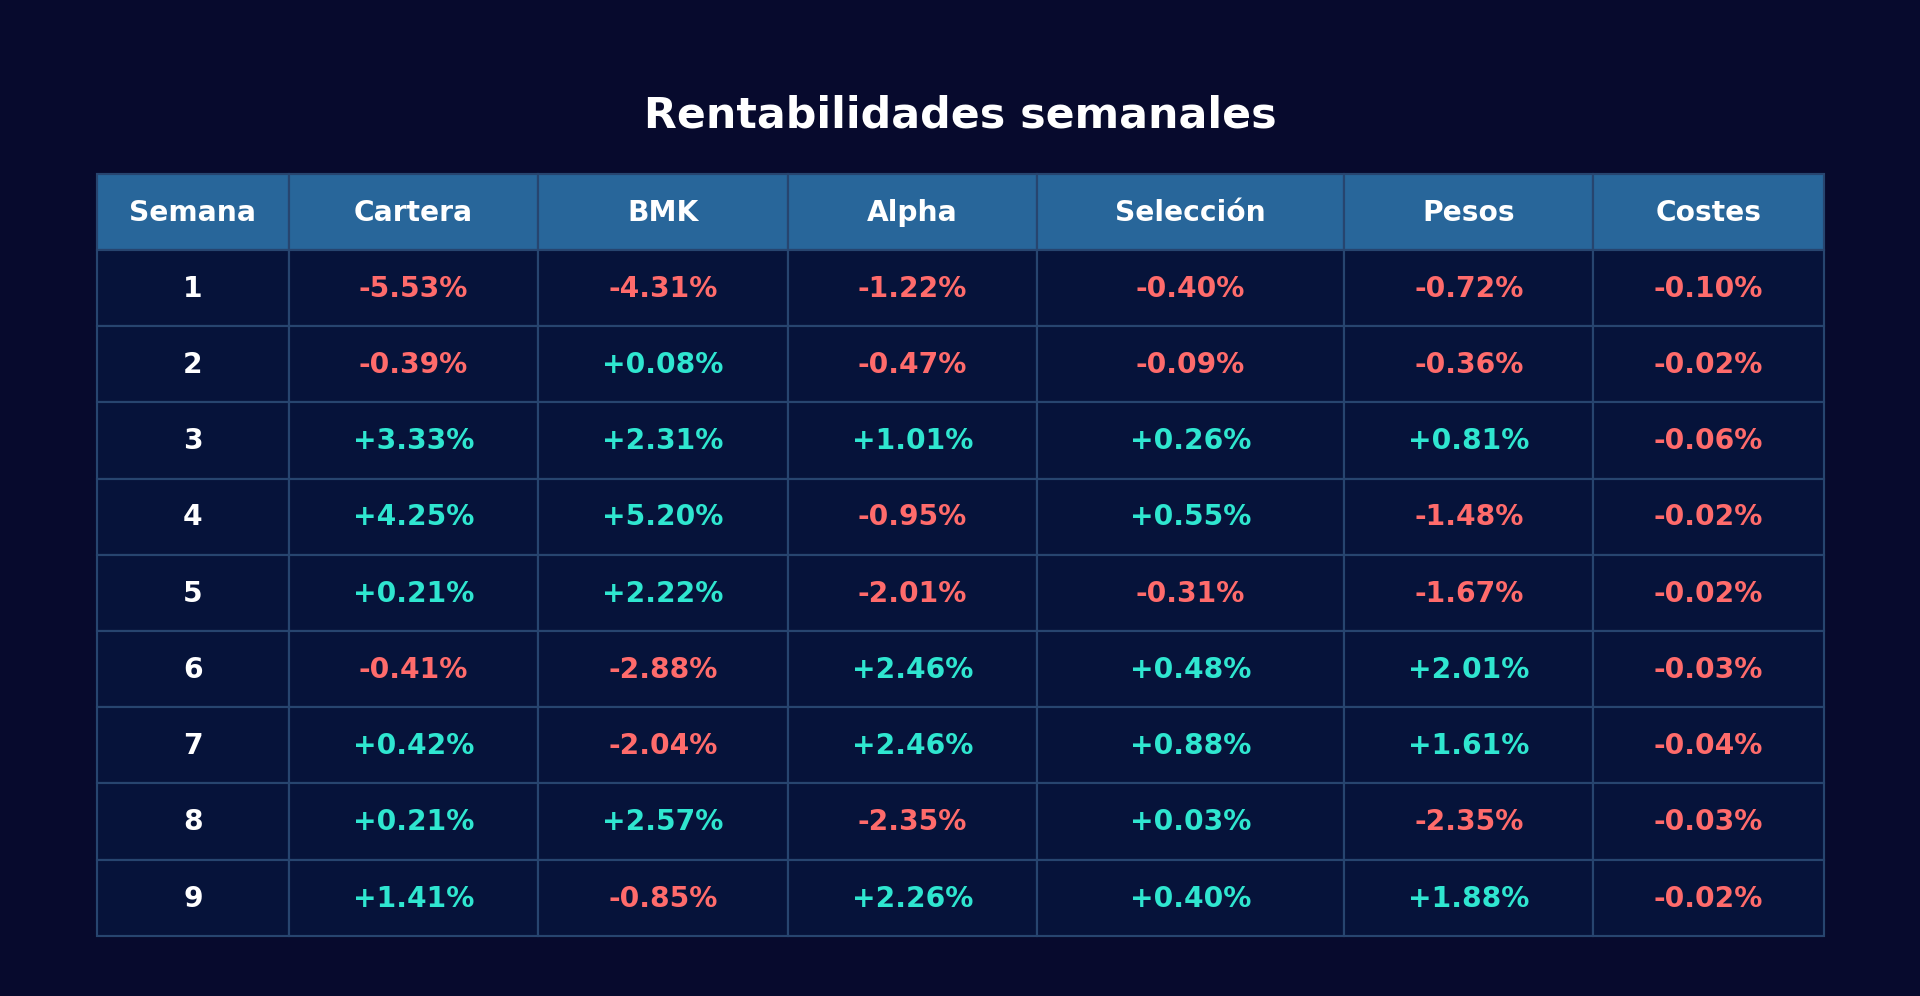

In [27]:
fig, ax = auxfun.tabla_semanal_presentacion(
    semanal,
    ultimas=10
)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:587: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  + final["Ef. pesos (€)"]


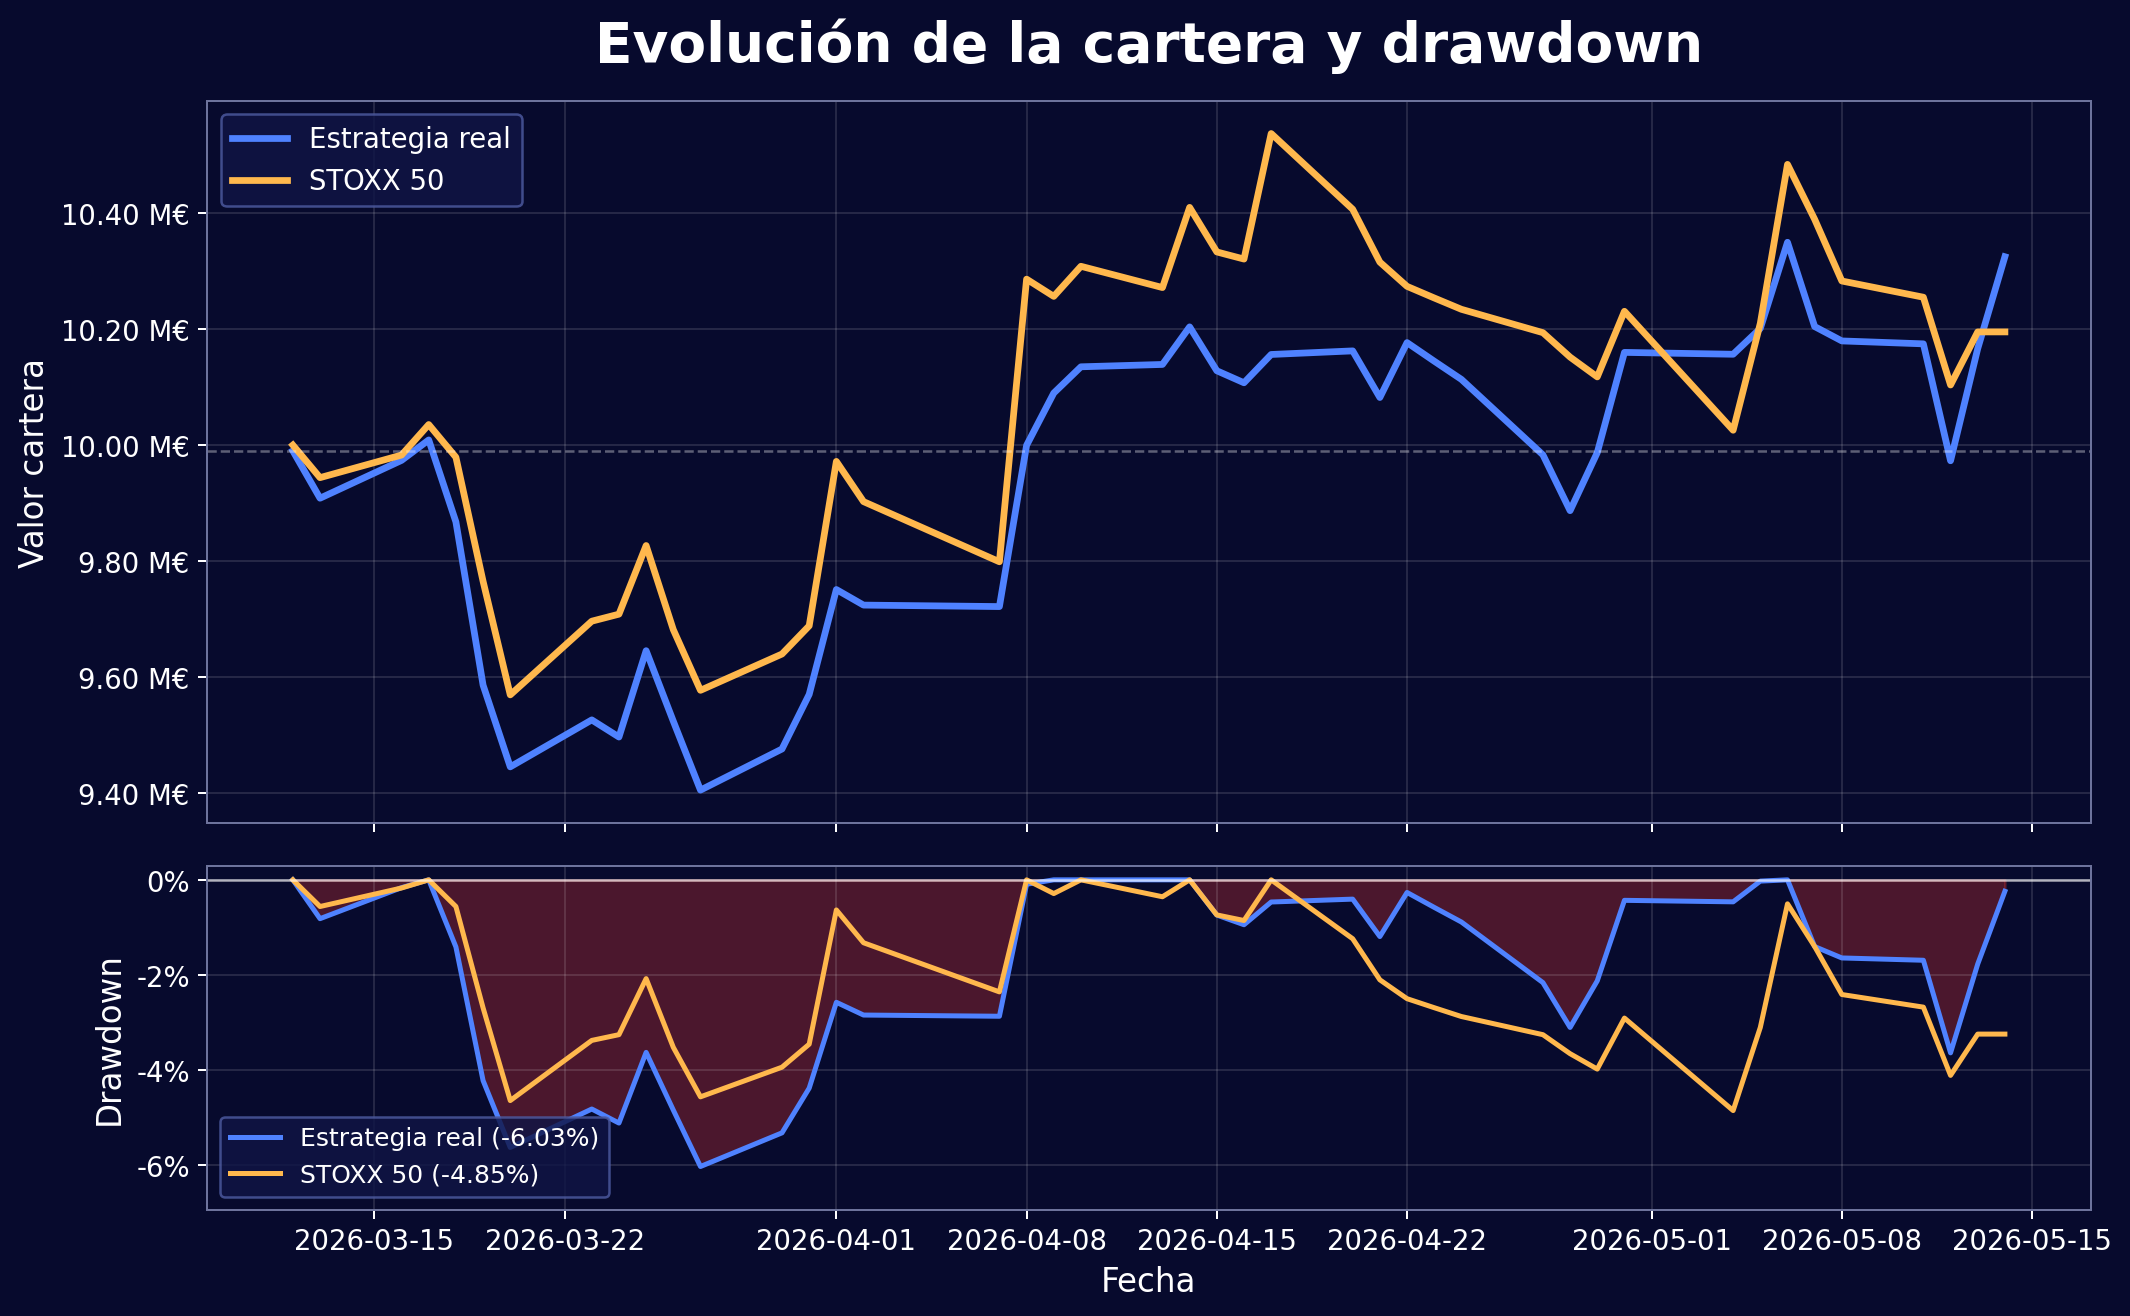

In [28]:
fig, axes = auxfun.grafico_evolucion_drawdown(
    series_grafico,
    titulo="Evolución de la cartera y drawdown"
)

In [29]:
display(final)

NAV cartera              1.032475e+07
NAV BMK                  1.019513e+07
Rentabilidad cartera     3.247537e-02
Rentabilidad BMK         1.951328e-02
Resultado cartera (€)    3.247537e+05
Efecto mercado (€)       1.951328e+05
Alpha (€)                1.296209e+05
Ef. selección (€)        1.832782e+05
Ef. pesos (€)           -1.797277e+04
Costes (€)              -3.568451e+04
Check alpha (€)         -5.486072e-09
Check NAV (€)           -5.529728e-09
dtype: float64

In [30]:
display(tabla_metricas_fmt)

Estrategia,Rentabilidad,Volatilidad,Max DD,Sharpe
Estrategia real,3.25%,18.89%,-6.03%,1.03
STOXX 50,1.95%,22.55%,-4.85%,0.54


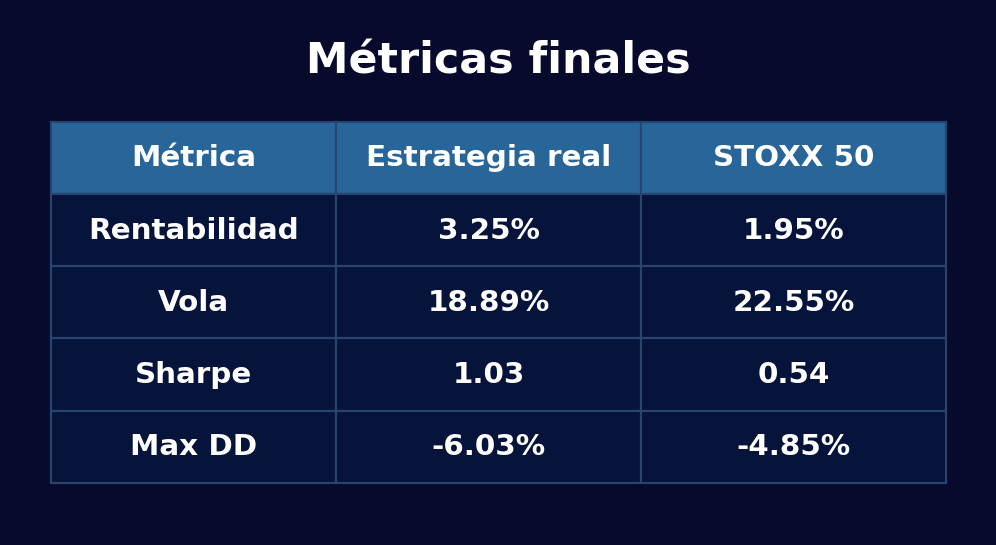

In [31]:
fig, ax = auxfun.tabla_metricas_presentacion(
    tabla_metricas, metricas=("Rentabilidad", "Volatilidad", "Sharpe", "Max DD")
)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:41: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ].copy()


P&L medio por activo: 12,490.25 €


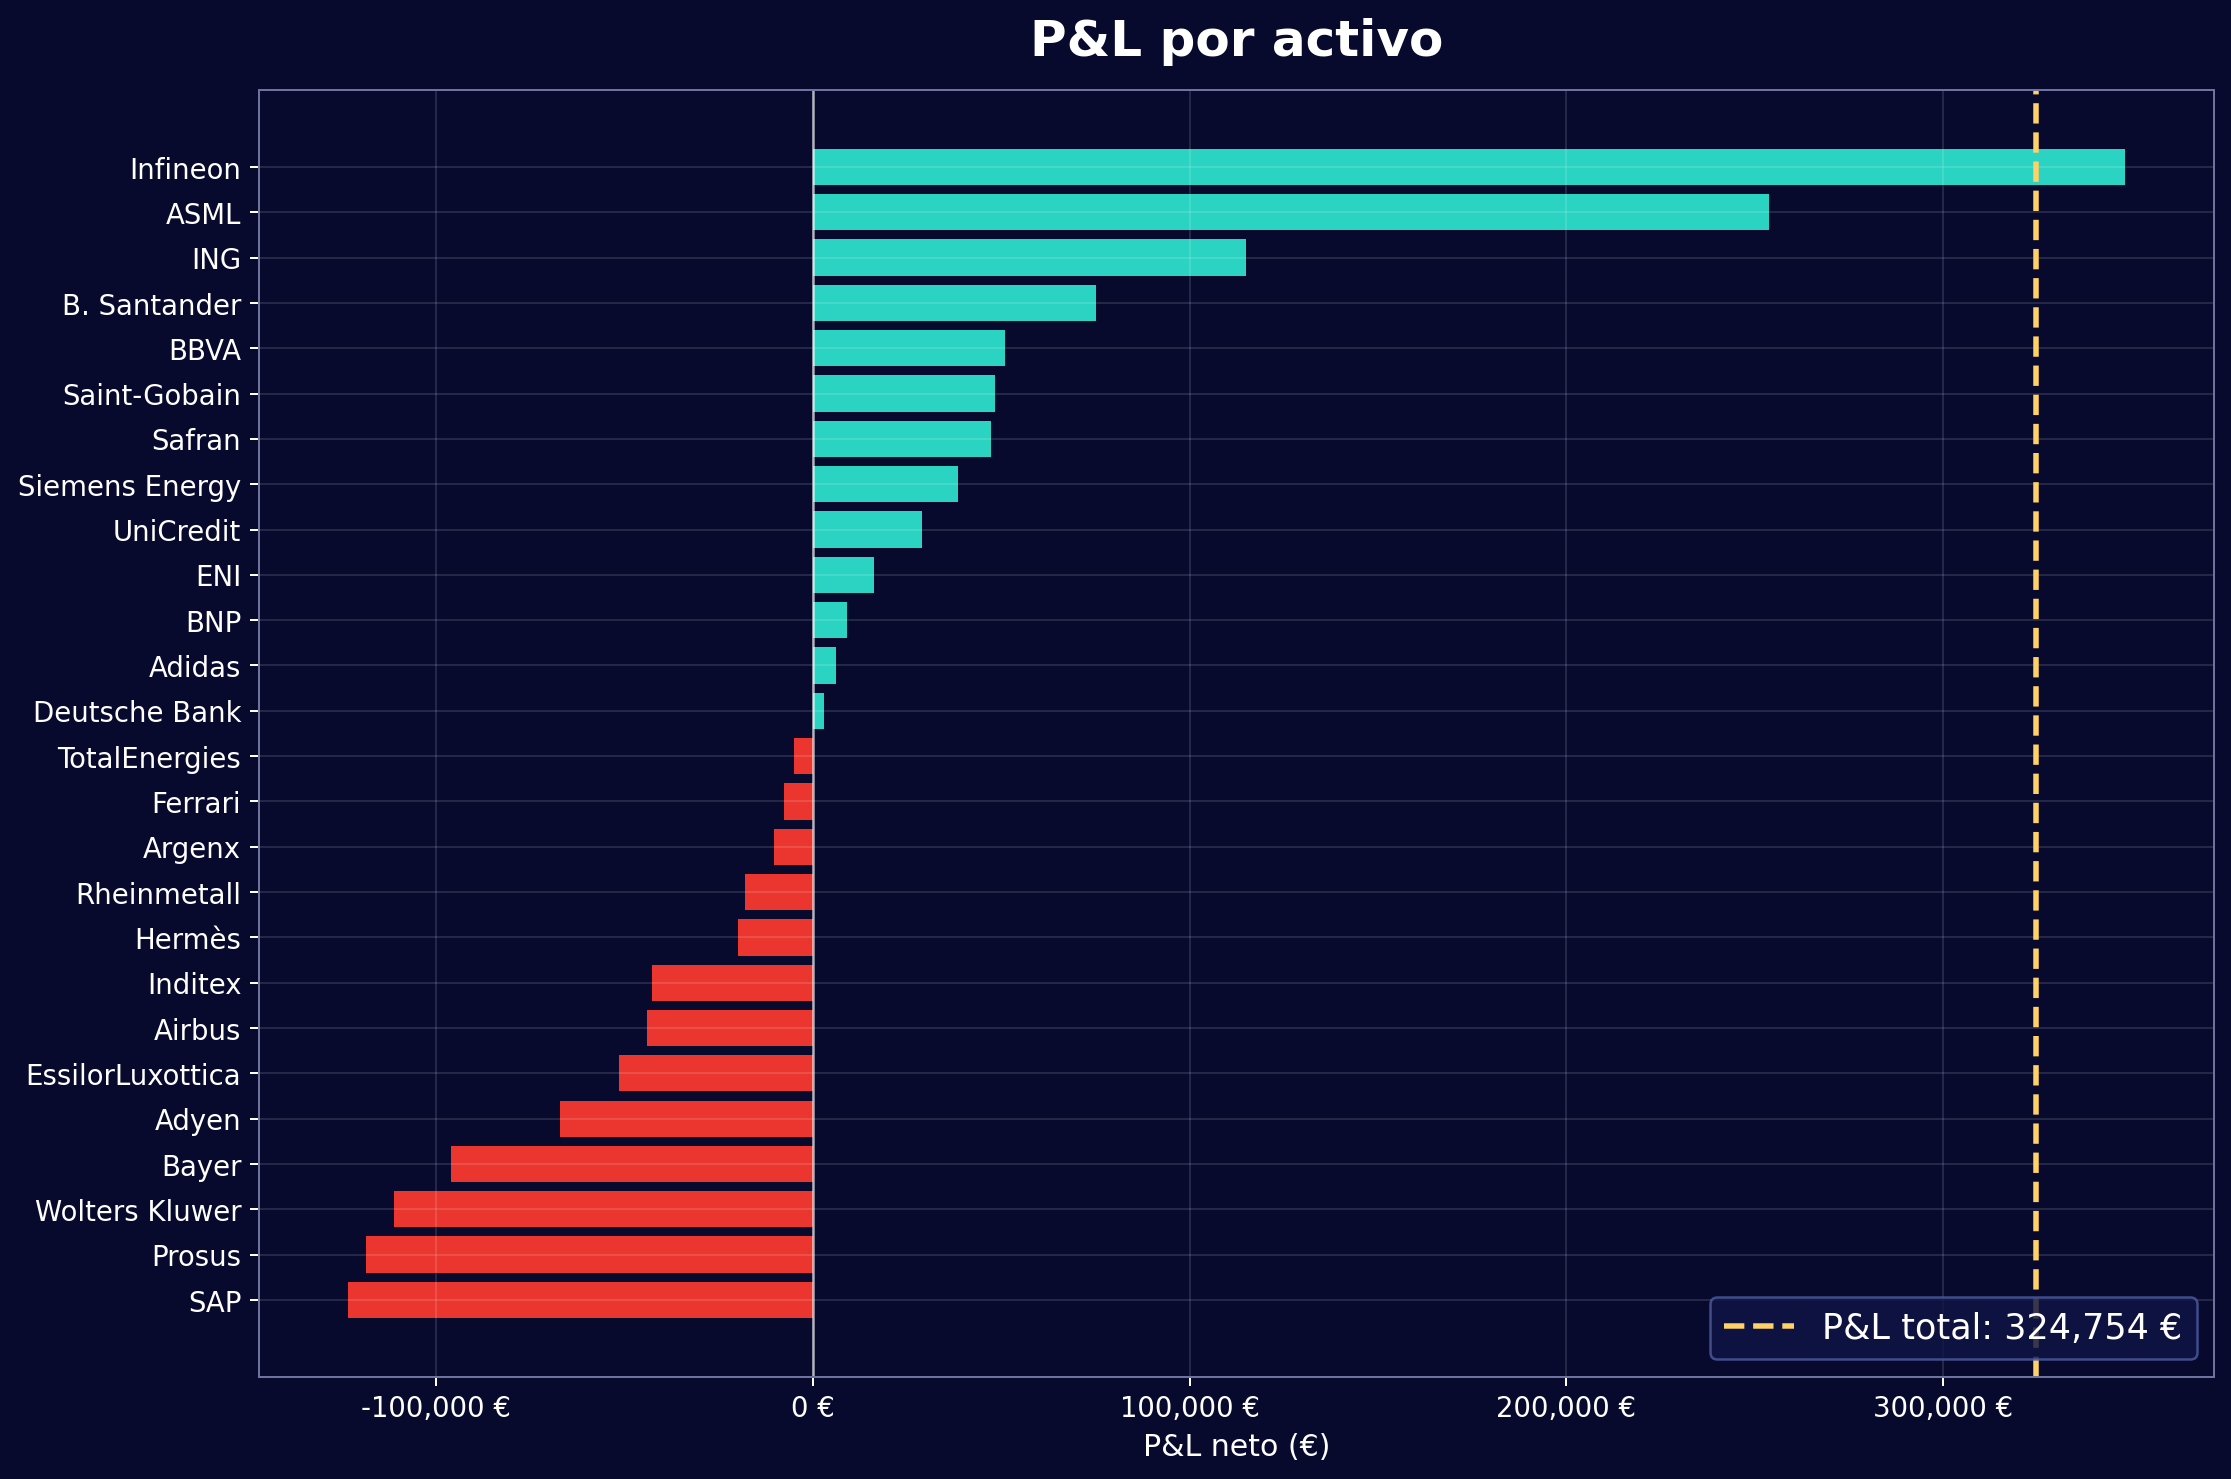

In [32]:
pnl_activos, fig, ax = auxfun.pnl_por_activo(
    archivo=path, fecha_fin=fecha_fin, capital_inicial=capital_inicial
)